### importing Pandas and csv file that containes data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import duckdb


In [32]:

#load data
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "eda":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "app" / "data" / "output" / "clean.csv"
df = pd.read_csv(DATA_PATH)
df.head()

df.head().to_dict()

{'event_id': {0: 'Z698xZq2Z1kAoaYe7',
  1: 'Z698xZq2Z16vv_fM-U',
  2: 'Z698xZq2Z1kqkOVqb',
  3: 'Z698xZq2Z1kaJxA4_',
  4: 'Z698xZq2Z16vPaqZG6'},
 'name': {0: 'STOCKHOLM INTERNATIONAL TAP DANCE FESTIVAL',
  1: 'Hussam Al Rassam',
  2: 'MAMMA MIA! THE PARTY',
  3: 'Daniel Midas w Sztokholmie',
  4: 'MAMMA MIA! THE PARTY'},
 'url': {0: 'https://www.ticketmaster.se/event/stockholm-international-tap-dance-festival-tickets/151270084?language=en-us',
  1: 'https://www.ticketmaster.se/event/hussam-al-rassam-tickets/1059537876?language=en-us',
  2: 'https://www.ticketmaster.se/event/mamma-mia-the-party-tickets/746834758?language=en-us',
  3: 'https://www.ticketmaster.se/event/daniel-midas-w-sztokholmie-tickets/266885559?language=en-us',
  4: 'https://www.ticketmaster.se/event/mamma-mia-the-party-tickets/1949740307?language=en-us'},
 'image_url': {0: 'https://s1.ticketm.net/dam/a/d2f/8582cce8-a129-4bfc-aa76-6afa0cec4d2f_SOURCE',
  1: 'https://s1.ticketm.net/dam/a/852/8e7f56cd-e0e6-458a-8a37-cffe

In [33]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] =(10, 5)

In [34]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(df["date"].dtype)
print(df["date"].min(), "->", df["date"].max())

datetime64[us]
2026-04-05 00:00:00 -> 2027-12-22 00:00:00


In [35]:
print("Shape:", df.shape)
print()
print("Dtypes:", df.dtypes)
print(df.dtypes)

Shape: (160, 22)

Dtypes: event_id                    str
name                        str
url                         str
image_url                   str
date             datetime64[us]
time                        str
status                      str
venue_id                    str
category_id               int64
segment                     str
genre                       str
subgenre                    str
venue_name                  str
venue_city                  str
venue_address               str
venue_lat               float64
venue_lon               float64
day_of_week                 str
month_name                  str
month_num                 int64
year                      int64
hour                    float64
dtype: object
event_id                    str
name                        str
url                         str
image_url                   str
date             datetime64[us]
time                        str
status                      str
venue_id                    str


In [36]:
print("Missing Values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate event_ids:", df["event_id"].duplicated().sum())

print("\nNumeric summary:")
df.describe()

Missing Values per column:
event_id         0
name             0
url              0
image_url        0
date             0
time             4
status           0
venue_id         0
category_id      0
segment          0
genre            0
subgenre         0
venue_name       0
venue_city       0
venue_address    1
venue_lat        0
venue_lon        0
day_of_week      0
month_name       0
month_num        0
year             0
hour             4
dtype: int64

Duplicate rows: 0
Duplicate event_ids: 0

Numeric summary:


,date,category_id,venue_lat,venue_lon,month_num,year,hour
count,160,160.000000,160.000000,160.000000,160.000000,160.000000,156.000000
mean,2026-08-02 21:18:00,5.412500,59.324916,18.081427,7.418750,2026.012500,17.891026
min,2026-04-05 00:00:00,1.000000,59.290450,18.000410,4.000000,2026.000000,1.000000
25%,2026-05-16 00:00:00,3.000000,59.324127,18.080810,5.000000,2026.000000,18.000000
50%,2026-07-22 12:00:00,5.000000,59.324127,18.096259,7.000000,2026.000000,19.000000
75%,2026-10-11 06:00:00,6.000000,59.324127,18.096259,10.000000,2026.000000,19.000000
max,2027-12-22 00:00:00,17.000000,59.372540,18.119030,12.000000,2027.000000,22.000000
std,NaN,3.335322,0.018678,0.029703,2.526518,0.111451,2.471969


In [37]:


duckdb.sql("""
    SELECT
        hour ,
        count(*) AS num_events
    From df
    WHERE hour IS NOT NULL
    GROUP BY hour
    ORDER BY num_events DESC
""")


┌────────┬────────────┐
│  hour  │ num_events │
│ double │   int64    │
├────────┼────────────┤
│   19.0 │         60 │
│   18.0 │         51 │
│   13.0 │         19 │
│   20.0 │         17 │
│   17.0 │          3 │
│   21.0 │          2 │
│   22.0 │          1 │
│   16.0 │          1 │
│   14.0 │          1 │
│    1.0 │          1 │
└────────┴────────────┘
  10 rows   2 columns

In [38]:
duckdb.sql("""
    SELECT
        hour ,
        count(*) AS num_events
    FROM df
    WHERE hour IS NOT NULL
    GROUP BY hour, segment
    Order By hour, num_events DESC
""")

┌────────┬────────────┐
│  hour  │ num_events │
│ double │   int64    │
├────────┼────────────┤
│    1.0 │          1 │
│   13.0 │         19 │
│   14.0 │          1 │
│   16.0 │          1 │
│   17.0 │          2 │
│   17.0 │          1 │
│   18.0 │         47 │
│   18.0 │          3 │
│   18.0 │          1 │
│   19.0 │         31 │
│   19.0 │         29 │
│   20.0 │         15 │
│   20.0 │          2 │
│   21.0 │          2 │
│   22.0 │          1 │
└────────┴────────────┘
  15 rows   2 columns

In [39]:

duckdb.sql("""
    SELECT
        CASE
            WHEN hour BETWEEN 6 AND 11 THEN 'Morning'
            WHEN hour BETWEEN 12 AND 17 THEN 'Afternoon'
            WHEN hour BETWEEN 18 AND 22 THEN 'Evening'
            ELSE 'Late night'
        END AS time_of_day
        FROM df
        WHERE hour IS NOT NULL
        GROUP BY time_of_day
        ORDER BY COUNT(*) DESC
""")

┌─────────────┐
│ time_of_day │
│   varchar   │
├─────────────┤
│ Evening     │
│ Afternoon   │
│ Late night  │
└─────────────┘

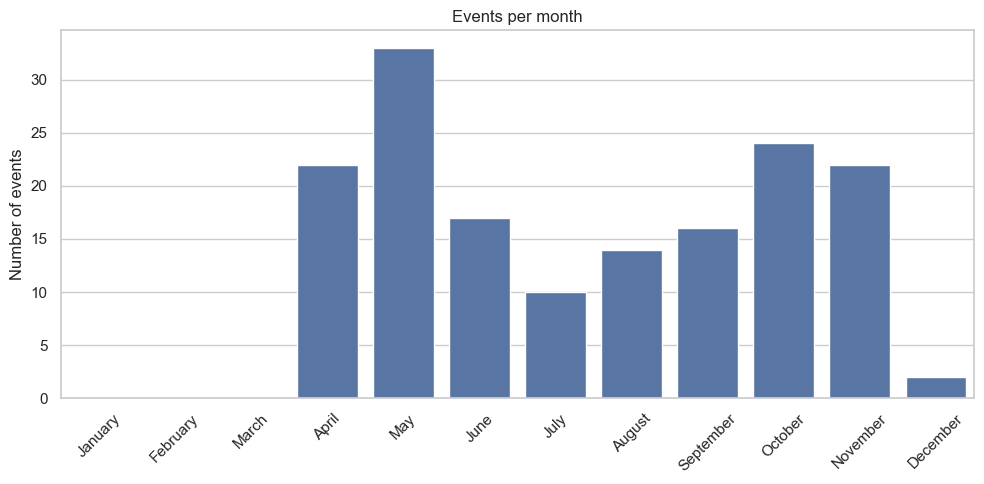

In [40]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

events_per_month = df["month_name"].value_counts().reindex(month_order, fill_value=0)

fig, ax = plt.subplots()
sns.barplot(x=month_order, y=events_per_month, ax=ax)
ax.set_title("Events per month")
ax.set_ylabel("Number of events")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

saved: /Users/lillmossi/Documents/github/Visualization_project/app/data/output/imag


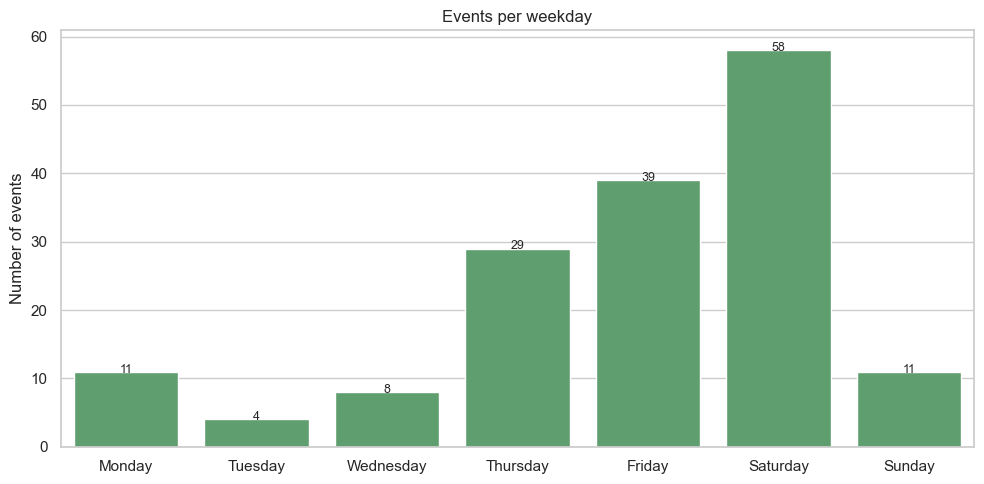

In [41]:
weekday_order = ["Monday", "Tuesday", "Wednesday",
                 "Thursday", "Friday", "Saturday", "Sunday"]

events_per_weekday = df["day_of_week"].value_counts().reindex(weekday_order, fill_value=0)

fig, ax = plt.subplots()
sns.barplot(x=events_per_weekday.index, y=events_per_weekday.values, ax=ax, color="#55A868")
ax.set_title("Events per weekday")
ax.set_ylabel("Number of events")
ax.set_xlabel("")

for i, v in enumerate(events_per_weekday.values):
    ax.text(i, v + 0.3, str(v), ha="center", va="center", fontsize=9)

plt.tight_layout()

imag_path = PROJECT_ROOT / "app" / "data" / "output" / "imag"
plt.savefig(imag_path, dpi=150, bbox_inches="tight")
print("saved:", imag_path)

plt.show()

saved: /Users/lillmossi/Documents/github/Visualization_project/app/data/output/imag


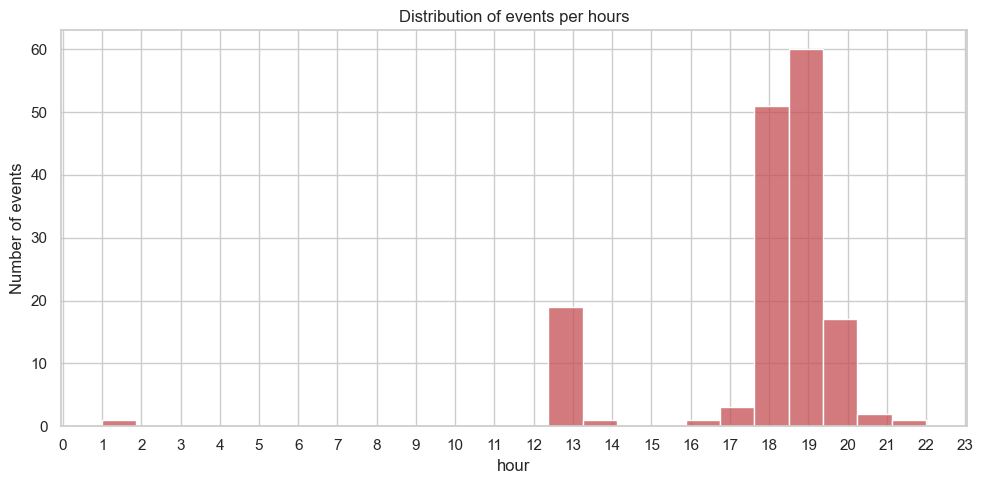

In [42]:
#events_per_hour = df["hour"].dropna().astype(int).values_counts().sort_index()

fig, ax = plt.subplots()
sns.histplot(data=df, x="hour", bins=24,color="#C44E52", edgecolor="white", ax=ax)
ax.set_title("Distribution of events per hours")
ax.set_ylabel("Number of events")
ax.set_xticks(range(0, 24))

plt.tight_layout()

imag_path = PROJECT_ROOT / "app" / "data" / "output" / "imag"
plt.savefig(imag_path, dpi=150, bbox_inches="tight")
print("saved:", imag_path)
plt.show()

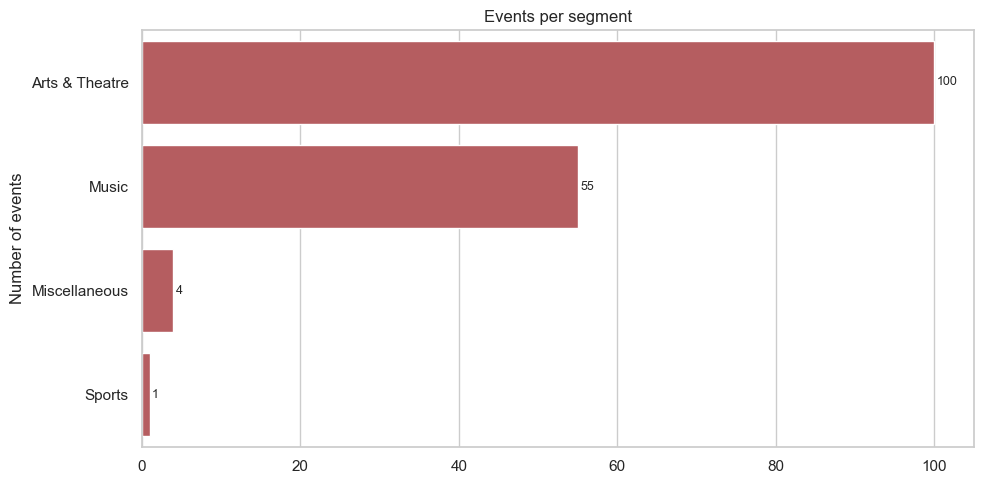

In [43]:
segment_count = df["segment"].value_counts()

fig, ax = plt.subplots()
sns.barplot(y=segment_count.index, x=segment_count.values, ax=ax, color="#C44E52", orient="h")
ax.set_title("Events per segment")
ax.set_ylabel("Number of events")
ax.set_xlabel("")
for i, v in enumerate(segment_count.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.tight_layout()

img_path = PROJECT_ROOT / "app" / "data" / "output" / "segment"
plt.savefig(img_path, dpi=150, bbox_inches="tight")
plt.show()

Saved: /Users/lillmossi/Documents/github/Visualization_project/eda/data_images/events_per_day.png


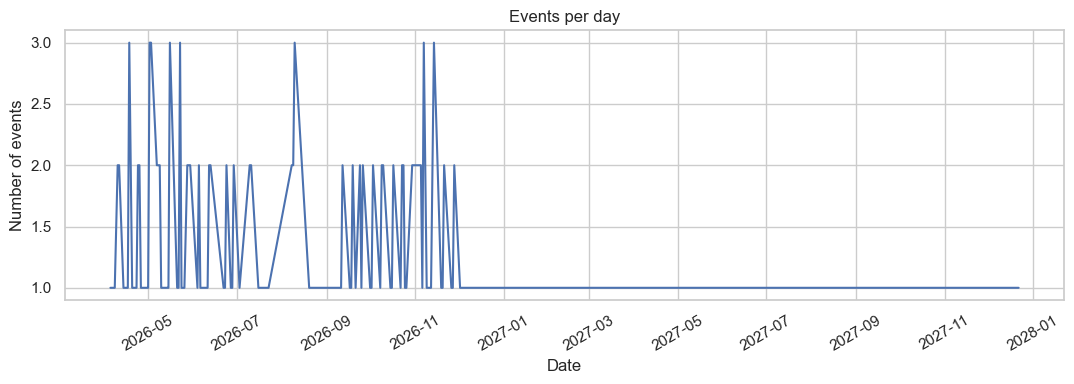

In [44]:
events_per_day = df.groupby(df["date"].dt.date).size()

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(x=events_per_day.index, y=events_per_day.values, ax=ax, color="#4C72B0")
ax.set_title("Events per day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of events")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

img_path = PROJECT_ROOT / "eda" / "data_images" / "events_per_day.png"
plt.savefig(img_path, dpi=150, bbox_inches="tight")
print("Saved:", img_path)

plt.show()